## Instalare pachete necesare

In [ ]:

!pip install langchain
!pip install langchain-community

!pip install python-docx
!pip install docx2txt
!pip install rank-bm25

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 13.2 MB/s eta 0:00:00


In [ ]:

!pip install faiss-cpu
!pip install sentence-transformers
!pip install transformers
!pip install torch
!pip install bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 11.4 MB/s eta 0:00:00


## Imports

In [ ]:
# Imports de bază pentru system și file handling
import os
import zipfile
import docx
import time
from typing import List, Tuple, Any
from io import BytesIO
import torch

# Google Colab specific
from google.colab import files

# LangChain imports
from langchain_community.document_loaders import DirectoryLoader, Docx2txtLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import FAISS
from langchain.schema import BaseRetriever, Document
from langchain.llms import HuggingFacePipeline
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate
from langchain.schema import Document

# Sentence Transformers pentru reranking
from sentence_transformers import CrossEncoder

# Utilities
import numpy as np
from tqdm.auto import tqdm

# Pentru debugging și progress tracking
from pprint import pprint


# Indexing

## Upload

In [ ]:

from google.colab import files
from io import BytesIO
import zipfile
import os
uploaded = files.upload()  # Selectezi arhiva ta .zip de pe laptop

# Numele fișierului zip (presupunem că e unul singur)
zip_name = next(iter(uploaded))
extract_dir = "/content/docx_folder"

# Creează folderul de extracție dacă nu există
os.makedirs(extract_dir, exist_ok=True)

# Extrage fișierele .docx
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

Saving Norme_BT.zip to Norme_BT.zip


## Load

In [ ]:
loader = DirectoryLoader(
    extract_dir + "/Norme_BT",
    glob="*.docx",
    loader_cls=Docx2txtLoader
)
documents = loader.load()
print(f"{len(documents)} docs.")

Am încărcat 29 documente.


In [ ]:
def docx_to_documents(docx_path):
    """
    Extracts text and tables from a .docx file and returns a list of LangChain Documents.
    Tables are converted to markdown format.
    Args:
        docx_path (str): Path to the .docx file.
    Returns:
        List[Document]: List of LangChain Documents.
    """
    doc = docx.Document(docx_path)
    documents = []
    full_text = []

    for element in doc.element.body:
        if element.tag.endswith('p'):
            paragraph = docx.text.paragraph.Paragraph(element, doc)
            full_text.append(paragraph.text)
        elif element.tag.endswith('tbl'):
            table = docx.table.Table(element, doc)
            markdown_table = ""
            for i, row in enumerate(table.rows):
                row_text = " | ".join([cell.text for cell in row.cells])
                markdown_table += f"| {row_text} |\n"
                if i == 0:
                    markdown_table += "| " + " | ".join(["---"] * len(row.cells)) + " |\n"
            full_text.append(markdown_table)

    documents.append(Document(page_content="\n".join(full_text), metadata={"source": docx_path}))
    return documents

all_documents = []
docx_folder = extract_dir + "/Norme_BT"
for filename in os.listdir(docx_folder):
    if filename.endswith(".docx"):
        file_path = os.path.join(docx_folder, filename)
        all_documents.extend(docx_to_documents(file_path))

print(f"Am încărcat {len(all_documents)} documente folosind loader-ul custom.")



## Split

In [ ]:
chunk_size = 130

tokenizer = AutoTokenizer.from_pretrained("intfloat/multilingual-e5-small")
text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
    tokenizer,
    chunk_size=chunk_size,
    chunk_overlap=int(chunk_size / 10),
    add_start_index=True,
    strip_whitespace=True,
    separators=["\n\n", "\n", ".", " ", ""],
)
docs = text_splitter.split_documents(documents)
print(f"Having {len(docs)} chunks.")



## Embed

In [ ]:
embeddings = HuggingFaceEmbeddings(model_name="intfloat/multilingual-e5-small")

embedded_docs = []
for doc in tqdm(docs, desc="Embedding documents"):
    embedded_docs.append(embeddings.embed_query(doc.page_content))

vectorstore = FAISS.from_embeddings(text_embeddings=list(zip([doc.page_content for doc in docs], embedded_docs)), embedding=embeddings)

In [ ]:
vectorstore.save_local("faiss_index")

# Indexing text + tables

## Load

In [ ]:
from docx import Document as DocxDocument
from langchain.docstore.document import Document
import pandas as pd
import os

def docx_to_documents(docx_path):
    """
    Extracts text and tables from a .docx file, returning LangChain Documents.
    Text and each table are stored as separate Documents, with tables as pandas DataFrames in metadata.
    Args:
        docx_path (str): Path to the .docx file.
    Returns:
        List[Document]: List of LangChain Documents (text and tables).
    """
    doc = DocxDocument(docx_path)
    documents = []
    text_content = []
    table_count = 0

    for element in doc.element.body:
        if element.tag.endswith('p'):
            paragraph = docx.text.paragraph.Paragraph(element, doc)
            if paragraph.text.strip():  # Skip empty paragraphs
                text_content.append(paragraph.text)
        elif element.tag.endswith('tbl'):
            table = docx.table.Table(element, doc)
            # Convert table to pandas DataFrame
            table_data = [[cell.text.strip() for cell in row.cells] for row in table.rows]
            if table_data and any(cell for row in table_data for cell in row):  # Skip empty tables
                df = pd.DataFrame(table_data[1:], columns=table_data[0] if table_data else None)
                # Create a Document for the table
                table_description = f"Table {table_count} from {os.path.basename(docx_path)}"
                documents.append(Document(
                    page_content=table_description,  # Embeddable description
                    metadata={
                        "source": docx_path,
                        "type": "table",
                        "table_index": table_count,
                        "table_df": df  # Store DataFrame in metadata
                    }
                ))
                table_count += 1

    # Create a Document for text content
    if text_content:  # Only if there's non-empty text
        documents.append(Document(
            page_content="\n".join(text_content),
            metadata={"source": docx_path, "type": "text"}
        ))

    return documents

# Load all documents
all_documents = []
docx_folder = extract_dir + "/Norme_BT"
for filename in os.listdir(docx_folder):
    if filename.endswith(".docx"):
        file_path = os.path.join(docx_folder, filename)
        all_documents.extend(docx_to_documents(file_path))

print(f"Loaded {len(all_documents)} documents (text and tables).")

FileNotFoundError: [Errno 2] No such file or directory: '/content/docx_folder/Norme_BT'

## Split

In [ ]:
from transformers import AutoTokenizer

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("intfloat/multilingual-e5-small")

# Initialize text splitter for text documents
text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
    tokenizer,
    chunk_size=200,  # Increased for better context
    chunk_overlap=20,  # 10% overlap
    strip_whitespace=True,
    separators=["\n\n", "\n", ".", "!", "?", " ", ""],  # Added ! and ? for technical docs
)

# Split documents, keeping tables intact
docs = []
for doc in all_documents:
    if doc.metadata["type"] == "text":
        # Split text documents
        split_docs = text_splitter.split_documents([doc])
        docs.extend(split_docs) # extend makes an append for each element of the split_docs (for each chunk)
    else:
        # Keep table documents intact
        docs.append(doc)

print(f"Split into {len(docs)} chunks (text chunks and full tables).")

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (6587 > 512). Running this sequence through the model will result in indexing errors


Split into 1798 chunks (text chunks and full tables).


## Embed

In [ ]:
# Initialize embeddings
embeddings = HuggingFaceEmbeddings(model_name="intfloat/multilingual-e5-small")

# Batch embedding
def batch_embed_documents(docs, batch_size=32):
    texts = [doc.page_content for doc in docs]
    batches = [texts[i:i + batch_size] for i in range(0, len(texts), batch_size)]
    embedded_docs = []

    for batch in tqdm(batches, desc="Embedding documents"):
        batch_embeddings = embeddings.embed_documents(batch)
        embedded_docs.extend(batch_embeddings)

    return list(zip(texts, embedded_docs))

# Embed documents
text_embeddings = batch_embed_documents(docs)

# Create FAISS vector store with metadata
vectorstore = FAISS.from_embeddings(
    text_embeddings=text_embeddings,
    embedding=embeddings,
    metadatas=[doc.metadata for doc in docs]
)

print("Created FAISS vector store.")

/tmp/ipython-input-3850737679.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="intfloat/multilingual-e5-small")


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Embedding documents:   0%|          | 0/57 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Created FAISS vector store.


In [ ]:
vectorstore.save_local("faiss_index")

# Index semanticaly

## Analyse

In [ ]:
!pip install python-docx

In [ ]:
import os
import zipfile
import docx
import pandas as pd
from typing import List, Dict, Any
from collections import defaultdict

# Assuming extract_dir is defined from previous steps
# If not, define it here:
extract_dir = "/content/docx_folder"
docx_folder = os.path.join(extract_dir, "Norme_BT")

# Check if the extracted folder exists
if not os.path.exists(docx_folder):
    print(f"Directory not found: {docx_folder}. Please ensure the zip file was uploaded and extracted.")
else:
    print(f"Analyzing paragraphs in documents located at: {docx_folder}")

    paragraph_data = []

    # Iterate through each docx file in the specified folder
    for filename in os.listdir(docx_folder):
        if filename.endswith(".docx"):
            file_path = os.path.join(docx_folder, filename)
            doc_name = os.path.basename(file_path)

            try:
                doc = docx.Document(file_path)

                # Iterate through each paragraph in the document
                for paragraph in doc.paragraphs:
                    paragraph_data.append({
                        "document_name": doc_name,
                        "style_name": paragraph.style.name,
                        "text": paragraph.text.strip()
                    })

                print(f"✅ Analyzed paragraphs in '{doc_name}'.")

            except Exception as e:
                print(f"❌ Error analyzing '{doc_name}': {e}")

    print(f"\nCollected data for {len(paragraph_data)} paragraphs from all documents.")

    # Now, perform some analysis on the collected paragraph_data

    # Count paragraphs by style name
    style_counts = defaultdict(int)
    for p in paragraph_data:
        style_counts[p["style_name"]] += 1

    print("\nParagraph counts by style name:")
    for style, count in style_counts.items():
        print(f"  {style}: {count}")

    # # Find the first 3 paragraphs with 'Title' style
    # title_paragraphs = [p["text"] for p in paragraph_data if p["style_name"] == "Title" and p["text"]]
    # print("\nFirst 3 Title paragraphs (if any):")
    # for i, title in enumerate(title_paragraphs[:3]):
    #     print(f"  {i+1}. {title}")
    # if not title_paragraphs:
    #     print("  No Title paragraphs found.")

    # Count paragraphs with 'Heading' styles (subtitles)
    subtitle_count = sum(count for style, count in style_counts.items() if style.startswith("Heading") and style != "Heading1" and style != "Title")
    print(f"\nNumber of subtitle paragraphs (Heading 2, Heading 3, etc.): {subtitle_count}")

    # You can add more analysis here as needed
    # For example, finding paragraphs with specific keywords, analyzing average paragraph length, etc.

Analyzing paragraphs in documents located at: /content/docx_folder/Norme_BT
✅ Analyzed paragraphs in 'Flux operational - Inrolare si deschidere cont PJ prin BT Stup.docx'.
✅ Analyzed paragraphs in 'Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta.docx'.
✅ Analyzed paragraphs in 'Conditiile generale de afaceri PJ.docx'.
✅ Analyzed paragraphs in 'Flux operational Modificare drepturi de operare imputernicit-delegat.docx'.
✅ Analyzed paragraphs in 'Flux operational - Inrolare si deschidere cont PJ in Client Enrollment.docx'.
✅ Analyzed paragraphs in 'Flux operational Autorizare date identificare PJ.docx'.
✅ Analyzed paragraphs in 'Flux operational privind serviciul ONRC.docx'.
✅ Analyzed paragraphs in 'Flux operational Iesirea din insolventa.docx'.
✅ Analyzed paragraphs in 'Procedura gestionare relatie afaceri PJ Mari Clienti Corporativi din punct de vedere operational.docx'.
✅ Analyzed paragraphs in 'Flux activare modificare dezactivare pachete PJ in BTOne

In [ ]:
sorted_style_counts = sorted(style_counts.items(), key=lambda item: item[1], reverse=True)

print("\nParagraph counts by style name (sorted descending):")
for style, count in sorted_style_counts:
  print(f"  {style}: {count}")


Paragraph counts by style name (sorted descending):
  Normal: 4449
  List Paragraph: 3100
  Normal (Web): 290
  Body Text: 116
  Heading 2: 92
  Plain Text: 84
  Heading 1: 56
  toc 2: 44
  x_x_msonormal: 40
  Style1: 39
  Body Text 2: 37
  No Spacing: 27
  toc 1: 27
  Default: 23
  Heading 3: 21
  toc 3: 19
  Titlu1: 16
  Body Text 3: 15
  annotation text: 13
  msolistparagraph: 13
  Subtitlu: 10
  Texte: 8
  Title: 8
  Heading G: 7
  Header: 6
  Subtitle: 6
  Body Text Indent: 4
  Footer: 4
  BT Norme-Proceduri: 3
  footnote text: 1
  x_msolistparagraph: 1
  envelope return: 1
  pf0: 1


In [ ]:
# Assuming paragraph_data and style_counts are available from the previous cell (htL9bIx6-sJ7)

# Check if paragraph_data and style_counts are defined
if 'paragraph_data' not in globals() or 'style_counts' not in globals():
    print("Variables 'paragraph_data' or 'style_counts' not found. Please run the previous cell (htL9bIx6-sJ7) first.")
else:
    print("\nParagraphs with styles appearing less than 100 times, grouped by style name:")
    print("=" * 80)

    # Filter paragraphs with styles appearing less than 100 times
    filtered_paragraphs = [
        p for p in paragraph_data if style_counts.get(p["style_name"], 0) < 100 and p["text"] # Include only non-empty text
    ]

    # Group filtered paragraphs by style name
    grouped_paragraphs = defaultdict(list)
    for paragraph in filtered_paragraphs:
        grouped_paragraphs[paragraph["style_name"]].append(paragraph)

    # Sort the style names alphabetically for consistent output
    sorted_style_names = sorted(grouped_paragraphs.keys())

    # Print paragraphs for each style group
    for style_name in sorted_style_names:
        paragraphs_in_style = grouped_paragraphs[style_name]
        print(f"\n--- Style: {style_name} (Count: {style_counts.get(style_name, 0)}) ---")
        for paragraph in paragraphs_in_style:
            print(f"Document: {paragraph['document_name']}")
            print(f"Text: {paragraph['text']}")
            print("-" * 20) # Separator for readability


Paragraphs with styles appearing less than 100 times, grouped by style name:

--- Style: Body Text 2 (Count: 37) ---
Document: Conditiile generale de afaceri PJ.docx
Text: Clientul va fi informat în mod gratuit despre operațiunile efectuate în contul său de depozit prin emiterea unui extras de cont lunar.
--------------------
Document: Conditiile generale de afaceri PJ.docx
Text: VIII.1. CARDURI PENTRU PERSOANE JURIDICE: VISA BUSINESS CLASSIC(DEBIT), VISA BUSINESS SILVER (DEBIT ȘI CREDIT), VISA BUSINESS GOLD (DEBIT/CREDIT), MASTERCARD BUSINESS (DEBIT cu cont în EUR)
--------------------
Document: Conditiile generale de afaceri PJ.docx
Text: Banca nu este obligată să accepte nici un document emis în altă limbă decât cea română, cu excepția cazului în care este altfel stipulat în Convenția încheiată cu Clientul. În acest caz, Banca va solicita Clientului să-i furnizeze o traducere autorizată în limba română a unui astfel de document legalizată de un notar public.
--------------------
Do

### Distribution of Word Counts for 'Normal' Style Paragraphs

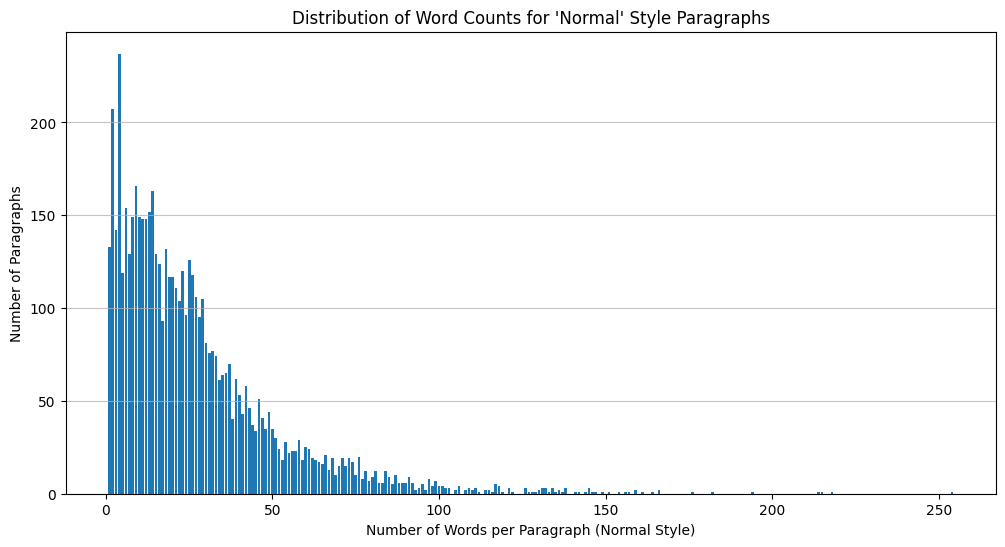


Analyzed 5809 'Normal' style paragraphs.


In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Assuming paragraph_data is available from the previous analysis cell (htL9bIx6-sJ7)

# Check if paragraph_data is defined
if 'paragraph_data' not in globals():
    print("Variable 'paragraph_data' not found. Please run the analysis cell (htL9bIx6-sJ7) first.")
else:
    # Filter for paragraphs with 'Normal' style and non-empty text
    # normal_paragraphs = [p for p in paragraph_data if p["style_name"] in ["Normal", "List Paragraph"]  and p["text"]]
    normal_paragraphs = [p for p in paragraph_data if p["text"]]

    # Calculate word count for each 'Normal' paragraph
    word_counts = [len(p["text"].split()) for p in normal_paragraphs]

    # Create a frequency distribution of word counts
    word_count_distribution = Counter(word_counts)

    # Prepare data for plotting
    words = sorted(word_count_distribution.keys())
    counts = [word_count_distribution[word] for word in words]

    # Create the bar plot
    plt.figure(figsize=(12, 6))
    plt.bar(words, counts)
    plt.xlabel("Number of Words per Paragraph (Normal Style)")
    plt.ylabel("Number of Paragraphs")
    plt.title("Distribution of Word Counts for 'Normal' Style Paragraphs")
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    print(f"\nAnalyzed {len(normal_paragraphs)} 'Normal' style paragraphs.")

### Formula

In [ ]:
# Assuming paragraph_data is available from a previous cell (e.g., htL9bIx6-sJ7)

# Check if paragraph_data is defined
if 'paragraph_data' not in globals():
    print("Variable 'paragraph_data' not found. Please run the paragraph analysis cell first.")
else:
    search_strings = [
        "Formula de calcul a dobânzii este",
        "Valoarea nominală X Nr. efectiv de zile din perioadă X Rata dobânzii"
    ]

    print("Searching for specified text within paragraphs:")
    print("=" * 60)

    found_paragraphs = []

    for paragraph in paragraph_data:
        paragraph_text = paragraph["text"]
        style_name = paragraph["style_name"]
        doc_name = paragraph["document_name"]

        # Check if the paragraph text contains either of the search strings
        if any(search_string.lower() in paragraph_text.lower() for search_string in search_strings):
            found_paragraphs.append(paragraph)

    # Print the details of the found paragraphs
    if found_paragraphs:
        print(f"Found {len(found_paragraphs)} paragraphs containing the specified text.")
        for i, p in enumerate(found_paragraphs):
            print(f"\n--- Paragraph {i+1} ---")
            print(f"Document: {p['document_name']}")
            print(f"Style: {p['style_name']}")
            print(f"Text: {p['text']}")
    else:
        print("No paragraphs containing the specified text were found.")

Searching for specified text within paragraphs:
Found 2 paragraphs containing the specified text.

--- Paragraph 1 ---
Document: Conditiile generale de afaceri PJ.docx
Style: Body Text Indent
Text: Formula de calcul a dobânzii este :

--- Paragraph 2 ---
Document: Conditiile generale de afaceri PJ.docx
Style: Body Text Indent
Text: D = Valoarea nominală X Nr. efectiv de zile din perioadă X Rata dobânzii


### Body Text Indent style pentru formaula

In [ ]:
# Assuming paragraph_data is available from a previous cell (e.g., htL9bIx6-sJ7)

# Check if paragraph_data is defined
if 'paragraph_data' not in globals():
    print("Variable 'paragraph_data' not found. Please run the paragraph analysis cell first.")
else:
    target_style = "Body Text Indent"
    print(f"Searching for paragraphs with style: '{target_style}'")
    print("=" * 60)

    found_paragraphs = [p for p in paragraph_data if p["style_name"] == target_style]

    if found_paragraphs:
        print(f"Found {len(found_paragraphs)} paragraphs with style '{target_style}':")
        for i, p in enumerate(found_paragraphs):
            print(f"\n--- Paragraph {i+1} (Document: {p['document_name']}) ---")
            print(p["text"])
    else:
        print(f"No paragraphs found with style '{target_style}'.")

Searching for paragraphs with style: 'Body Text Indent'
Found 4 paragraphs with style 'Body Text Indent':

--- Paragraph 1 (Document: Conditiile generale de afaceri PJ.docx) ---


--- Paragraph 2 (Document: Conditiile generale de afaceri PJ.docx) ---
Formula de calcul a dobânzii este :

--- Paragraph 3 (Document: Conditiile generale de afaceri PJ.docx) ---
D = Valoarea nominală X Nr. efectiv de zile din perioadă X Rata dobânzii

--- Paragraph 4 (Document: Conditiile generale de afaceri PJ.docx) ---
360 X 100


### Exista alte formule?

In [ ]:
# Assuming paragraph_data is available from a previous cell (e.g., htL9bIx6-sJ7)

# Check if paragraph_data is defined
if 'paragraph_data' not in globals():
    print("Variable 'paragraph_data' not found. Please run the paragraph analysis cell first.")
else:
    search_keyword = "formula"
    print(f"Searching for paragraphs containing the keyword: '{search_keyword}'")
    print("=" * 60)

    found_paragraphs = []

    for paragraph in paragraph_data:
        paragraph_text = paragraph["text"]
        style_name = paragraph["style_name"]
        doc_name = paragraph["document_name"]

        # Check if the keyword is in the paragraph text (case-insensitive)
        if search_keyword.lower() in paragraph_text.lower():
            found_paragraphs.append(paragraph)

    # Print the details of the found paragraphs
    if found_paragraphs:
        print(f"Found {len(found_paragraphs)} paragraphs containing '{search_keyword}':")
        for i, p in enumerate(found_paragraphs):
            print(f"\n--- Paragraph {i+1} ---")
            print(f"Document: {p['document_name']}")
            print(f"Style: {p['style_name']}")
            print(f"Text: {p['text']}")
            print("-" * 20) # Separator for readability
    else:
        print(f"No paragraphs containing '{search_keyword}' were found.")

Searching for paragraphs containing the keyword: 'formula'
Found 353 paragraphs containing 'formula':

--- Paragraph 1 ---
Document: Flux operational - Inrolare si deschidere cont PJ prin BT Stup.docx
Style: List Paragraph
Text: În vederea înrolării companiei după înființarea acesteia la Registrul Comerțului, clientul va semna în prezența unui Operator BT, Cererea pentru deschiderea relatiei contractuale si achizitionarea de produse bancare pentru persoane juridice in curs de constituire si inrolare persoane fizice non-titulari, prin BT STUP (Anexa nr. Cod 36.3) din Colectia de anexe si formulare utilizate in aplicarea standardelor de cunoastere a clientelei in scopul prevenirii spalarii banilor si finantarii terorismului (C.3.94._).
--------------------

--- Paragraph 2 ---
Document: Flux operational - Inrolare si deschidere cont PJ prin BT Stup.docx
Style: List Paragraph
Text: Acesta reprezintă „Documentul inițial” care stă la baza cererii formulate de client, respectiv de înrolare (

### links

In [ ]:
# Assuming paragraph_data is available from a previous cell (e.g., htL9bIx6-sJ7)

# Check if paragraph_data is defined
if 'paragraph_data' not in globals():
    print("Variable 'paragraph_data' not found. Please run the paragraph analysis cell first.")
else:
    target_style = "Normal (Web)"
    print(f"Searching for paragraphs with style: '{target_style}'")
    print("=" * 60)

    found_paragraphs = [p for p in paragraph_data if p["style_name"] == target_style and p["text"]]

    if found_paragraphs:
        print(f"Found {len(found_paragraphs)} paragraphs with style '{target_style}':")
        for i, p in enumerate(found_paragraphs):
            print(f"\n--- Paragraph {i+1} (Document: {p['document_name']}) ---")
            print(f"Text: {p['text']}")
    else:
        print(f"No paragraphs found with style '{target_style}'.")

Searching for paragraphs with style: 'Normal (Web)'
Found 217 paragraphs with style 'Normal (Web)':

--- Paragraph 1 (Document: Conditiile generale de afaceri PJ.docx) ---
Text: Token de plată: număr de card alternativ asociat fiecărui card înrolat în aplicațiile de plată, din motive de securitate.  Tokenul de plată poate fi utilizat doar de către aplicația de plată în care a fost înregistrat.

--- Paragraph 2 (Document: Conditiile generale de afaceri PJ.docx) ---
Text: Tranzacție: operațiune efectuată cu cardul pentru:

--- Paragraph 3 (Document: Flux operational privind serviciul ONRC.docx) ---
Text: Certificat Constatator: prezintă starea la zi a firmei şi cuprinde următoarele informaţii:

--- Paragraph 4 (Document: Flux operational privind serviciul ONRC.docx) ---
Text: denumirea (firma);

--- Paragraph 5 (Document: Flux operational privind serviciul ONRC.docx) ---
Text: emblema;

--- Paragraph 6 (Document: Flux operational privind serviciul ONRC.docx) ---
Text: numărul de înregist

### links or common URL

In [ ]:
import os
import zipfile # Import zipfile
import docx # Import docx
from docx.oxml.ns import nsdecls
from docx.oxml import parse_xml
import re # Import re for regex

# Assuming extract_dir is defined from previous steps
# If not, define it here:
extract_dir = "/content/docx_folder"
docx_folder = os.path.join(extract_dir, "Norme_BT")

# Check if the extracted folder exists
if not os.path.exists(docx_folder):
    print(f"Directory not found: {docx_folder}. Please ensure the zip file was uploaded and extracted.")
else:
    print(f"Checking for links and references in documents located at: {docx_folder}")

    found_links = []
    common_url_patterns = [
        r"http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+",
        r"www\.(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+",
        r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}" # Basic email pattern
    ]

    # Iterate through each docx file in the specified folder
    for filename in os.listdir(docx_folder):
        if filename.endswith(".docx"):
            file_path = os.path.join(docx_folder, filename)
            doc_name = os.path.basename(file_path)

            try:
                doc = docx.Document(file_path)
                # Iterate through all paragraphs and tables
                for element in doc.element.body:
                    if element.tag.endswith('p'):
                        paragraph = docx.text.paragraph.Paragraph(element, doc)
                        # Check for explicit hyperlinks in runs
                        for run in paragraph.runs:
                            if 'hyperlink' in run._element.xml:
                                root = parse_xml(run._element.xml)
                                namespaces = {k: v for k, v in root.nsmap.items() if v}
                                for hyperlink in root.xpath('//a:hlink', namespaces=namespaces):
                                     if 'id' in hyperlink.attrib:
                                         link_id = hyperlink.attrib['id']
                                         # Find the relationship to get the URL
                                         try:
                                             rId = doc.part.rels[link_id]
                                             if rId.is_external:
                                                 found_links.append({"document": doc_name, "type": "hyperlink", "url": rId.target_ref, "text": run.text.strip()})
                                         except KeyError:
                                             # Handle cases where rId is not found (shouldn't happen for valid links)
                                             pass
                        # Check for common URL patterns and email addresses in plain text
                        text = paragraph.text
                        for pattern in common_url_patterns:
                            for match in re.finditer(pattern, text):
                                found_links.append({"document": doc_name, "type": "pattern_match", "text": match.group(0)})

                    elif element.tag.endswith('tbl'):
                        table = docx.table.Table(element, doc)
                        # Check for links within table cells
                        for row in table.rows:
                            for cell in row.cells:
                                for paragraph in cell.paragraphs:
                                     for run in paragraph.runs:
                                         if 'hyperlink' in run._element.xml:
                                            root = parse_xml(run._element.xml)
                                            namespaces = {k: v for k, v in root.nsmap.items() if v}
                                            for hyperlink in root.xpath('//a:hlink', namespaces=namespaces):
                                                 if 'id' in hyperlink.attrib:
                                                     link_id = hyperlink.attrib['id']
                                                     try:
                                                         rId = doc.part.rels[link_id]
                                                         if rId.is_external:
                                                             found_links.append({"document": doc_name, "type": "hyperlink", "url": rId.target_ref, "text": run.text.strip(), "location": "table"})
                                                     except KeyError:
                                                          pass
                                         # Check for common patterns in table cell text
                                         cell_text = paragraph.text
                                         for pattern in common_url_patterns:
                                             for match in re.finditer(pattern, cell_text):
                                                 found_links.append({"document": doc_name, "type": "pattern_match", "text": match.group(0), "location": "table"})


                print(f"✅ Checked '{doc_name}' for links.")

            except Exception as e:
                print(f"❌ Error checking '{doc_name}' for links: {e}")

    if found_links:
        print(f"\nFound {len(found_links)} potential links or references:")
        for link in found_links:
            print(link)
    else:
        print("No links or common URL patterns found in the documents.")

Checking for links and references in documents located at: /content/docx_folder/Norme_BT
✅ Checked 'Flux operational - Inrolare si deschidere cont PJ prin BT Stup.docx' for links.
✅ Checked 'Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta.docx' for links.
✅ Checked 'Conditiile generale de afaceri PJ.docx' for links.
✅ Checked 'Flux operational Modificare drepturi de operare imputernicit-delegat.docx' for links.
✅ Checked 'Flux operational - Inrolare si deschidere cont PJ in Client Enrollment.docx' for links.
✅ Checked 'Flux operational Autorizare date identificare PJ.docx' for links.
✅ Checked 'Flux operational privind serviciul ONRC.docx' for links.
✅ Checked 'Flux operational Iesirea din insolventa.docx' for links.
✅ Checked 'Procedura gestionare relatie afaceri PJ Mari Clienti Corporativi din punct de vedere operational.docx' for links.
✅ Checked 'Flux activare modificare dezactivare pachete PJ in BTOne.docx' for links.
✅ Checked 'Politica BT standa

### Sunt referinte?

In [ ]:
import os
import docx
import re

# Assuming extract_dir is defined from previous steps
extract_dir = "/content/docx_folder"
docx_folder = os.path.join(extract_dir, "Norme_BT")

# Check if the extracted folder exists
if not os.path.exists(docx_folder):
    print(f"Directory not found: {docx_folder}. Please ensure the zip file was uploaded and extracted.")
else:
    print(f"Checking for references in documents located at: {docx_folder}")

    found_references = []

    # Define patterns that might indicate references (e.g., document codes, "Anexa", "Referinta")
    # These patterns are examples and may need to be adjusted based on the specific document format
    reference_patterns = [
        r"\(F\.\d+\.\d+\.\d+\)",  # Example: (F.39.68.3)
        r"\(CGA\.\d+\.\d+\.\d+\)", # Example: (CGA.3.3.15)
        r"Anexa\s+\w+",          # Example: Anexa 4, Anexa 5
        r"Referin[tț]a:",        # Example: Referința:
        r"Cod\s+\d+"           # Example: Cod 18
    ]

    # Iterate through each docx file in the specified folder
    for filename in os.listdir(docx_folder):
        if filename.endswith(".docx"):
            file_path = os.path.join(docx_folder, filename)
            doc_name = os.path.basename(file_path)

            try:
                doc = docx.Document(file_path)
                # Iterate through all paragraphs and tables
                for element in doc.element.body:
                    if element.tag.endswith('p'):
                        paragraph = docx.text.paragraph.Paragraph(element, doc)
                        text = paragraph.text

                        # Check for reference patterns in paragraph text
                        for pattern in reference_patterns:
                            for match in re.finditer(pattern, text):
                                found_references.append({"document": doc_name, "type": "pattern_match", "text": match.group(0), "location": "paragraph"})

                    elif element.tag.endswith('tbl'):
                        table = docx.table.Table(element, doc)
                        # Check for reference patterns within table cells
                        for row in table.rows:
                            for cell in row.cells:
                                cell_text = cell.text
                                for pattern in reference_patterns:
                                    for match in re.finditer(pattern, cell_text):
                                        found_references.append({"document": doc_name, "type": "pattern_match", "text": match.group(0), "location": "table cell"})


                print(f"✅ Checked '{doc_name}' for references.")

            except Exception as e:
                print(f"❌ Error checking '{doc_name}' for references: {e}")

    if found_references:
        print(f"\nFound {len(found_references)} potential references:")
        for reference in found_references:
            print(reference)
    else:
        print("No specific reference patterns found in the documents.")

Checking for references in documents located at: /content/docx_folder/Norme_BT
✅ Checked 'Flux operational - Inrolare si deschidere cont PJ prin BT Stup.docx' for references.
✅ Checked 'Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta.docx' for references.
✅ Checked 'Conditiile generale de afaceri PJ.docx' for references.
✅ Checked 'Flux operational Modificare drepturi de operare imputernicit-delegat.docx' for references.
✅ Checked 'Flux operational - Inrolare si deschidere cont PJ in Client Enrollment.docx' for references.
✅ Checked 'Flux operational Autorizare date identificare PJ.docx' for references.
✅ Checked 'Flux operational privind serviciul ONRC.docx' for references.
✅ Checked 'Flux operational Iesirea din insolventa.docx' for references.
✅ Checked 'Procedura gestionare relatie afaceri PJ Mari Clienti Corporativi din punct de vedere operational.docx' for references.
✅ Checked 'Flux activare modificare dezactivare pachete PJ in BTOne.docx' for r

## Split by H1
how my data is splited by docx (29). split them by headings and give the metadata {docx_name, h1}. than add H2 and H3 in the same way

In [ ]:
import docx
import os
from typing import List, Dict, Any
from collections import defaultdict

# Assuming extract_dir is defined from previous steps
# extract_dir = "/content/docx_folder"
# docx_folder = os.path.join(extract_dir, "Norme_BT")

# Define H1 heading styles
h1_styles = ['toc 1', 'Heading 1', 'Titlu1']

h1s_df = pd.DataFrame(columns=["docx_name", "h1"])

# Check if the extracted folder exists
if not os.path.exists(docx_folder):
    print(f"Directory not found: {docx_folder}. Please ensure the zip file was uploaded and extracted.")
else:
    print("Splitting documents by H1 headings and extracting metadata...")
    print("---")

    all_sections_data = []

    # Iterate through each docx file in the specified folder
    for filename in os.listdir(docx_folder):
        if filename.endswith(".docx"):
            file_path = os.path.join(docx_folder, filename)
            doc_name = os.path.basename(file_path)

            try:
                doc = docx.Document(file_path)
                current_section_text = []
                current_h1 = None
                first_section = True

                for i, paragraph in enumerate(doc.paragraphs):
                    style_name = paragraph.style.name
                    text = paragraph.text.strip()

                    is_h1 = style_name in h1_styles

                    if is_h1:
                        # Process the previous section if it exists
                        if current_section_text or first_section:
                             # Handle the beginning of the document if it doesn't start with H1
                            if first_section and not current_h1 and (current_section_text or i == 0):
                                section_h1 = f"Beginning of {doc_name}"
                                # Add the first section data
                                all_sections_data.append({
                                    "docx_name": doc_name,
                                    "h1": section_h1,
                                    "content": "\n".join(current_section_text)
                                })
                            elif current_h1:
                                # Add the data for the section starting with the previous H1
                                all_sections_data.append({
                                    "docx_name": doc_name,
                                    "h1": current_h1,
                                    "content": "\n".join(current_section_text)
                                })


                        # Start a new section
                        current_h1 = text if text else f"Unnamed H1 ({style_name})" # Use text if not empty, otherwise a placeholder
                        current_section_text = []
                        first_section = False
                    else:
                        # Add paragraph text to the current section
                        current_section_text.append(text)

                # Add the last section after the loop finishes
                if current_section_text or first_section:
                    if first_section and not current_h1:
                         section_h1 = f"Beginning of {doc_name}"
                         all_sections_data.append({
                            "docx_name": doc_name,
                            "h1": section_h1,
                            "content": "\n".join(current_section_text)
                         })
                    elif current_h1:
                         all_sections_data.append({
                            "docx_name": doc_name,
                            "h1": current_h1,
                            "content": "\n".join(current_section_text)
                         })


                # print(f"✅ Processed '{doc_name}'. Found {len([p for p in doc.paragraphs if p.style.name in h1_styles])} H1s.")

                h1s_df = pd.concat([h1s_df, pd.DataFrame({"docx_name": [doc_name], "h1": [current_h1]})], ignore_index=True)

            except Exception as e:
                print(f"❌ Error processing '{doc_name}': {e}")


    print(f"\nExtracted metadata for {len(all_sections_data)} sections from all documents.")

    display(h1s_df)

    # Print the extracted metadata for each section
    print("\nExtracted Section Metadata:")
    print("=" * 30)
    for section in all_sections_data:
        print(f"Document: {section['docx_name']}")
        print(f"H1 Heading: {section['h1']}")
        print(f"Content snippet: {section['content'][:200]}...") # Print a snippet of the content
        print("-" * 20)

Splitting documents by H1 headings and extracting metadata...
---

Extracted metadata for 113 sections from all documents.


,docx_name,h1
0,Flux operational - Inrolare si deschidere cont...,None
1,Flux operational Inrolare si deschidere cont p...,Flux operational Inrolare si deschidere cont p...
2,Conditiile generale de afaceri PJ.docx,IX. ALTE CLAUZE
3,Flux operational Modificare drepturi de operar...,Anexa Documente utilizate in proces
4,Flux operational - Inrolare si deschidere cont...,None
5,Flux operational Autorizare date identificare ...,Flux operational Autorizare date identificare PJ
6,Flux operational privind serviciul ONRC.docx,IV. Contabilitate – Alimentarea userilor
7,Flux operational Iesirea din insolventa.docx,None
8,Procedura gestionare relatie afaceri PJ Mari C...,CAPITOLUL 5. SOLICITARI DE INFORMATII DIVERSE
9,Flux activare modificare dezactivare pachete P...,MOD DE LUCRU



Extracted Section Metadata:
Document: Flux operational - Inrolare si deschidere cont PJ prin BT Stup.docx
H1 Heading: Beginning of Flux operational - Inrolare si deschidere cont PJ prin BT Stup.docx
Content snippet: 
Lista de distributie interna:

Istoricul modificarilor:

Roluri implicate in proces:



Cuprins
A.	Inițierea relației de afaceri cu o companie, prin intermediul BT Stup	3
B.	Înrolarea clientului, des...
--------------------
Document: Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta.docx
H1 Heading: Beginning of Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta.docx
Content snippet: 



Lista de distributie interna:

Istoricul modificarilor:


Roluri implicate in proces:

CUPRINS...
--------------------
Document: Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta.docx
H1 Heading: Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta	4
Content snippet:

### not "beggingin"

In [ ]:
import docx
import os
import pandas as pd

# Example:
# docx_folder = "/content/docx_folder"

# Define H1 heading styles
h1_styles = ['toc 1', 'Heading 1', 'Titlu1']

h1s_df = pd.DataFrame(columns=["docx_name", "h1"])

if not os.path.exists(docx_folder):
    print(f"Directory not found: {docx_folder}. Please ensure the zip file was uploaded and extracted.")
else:
    print("Splitting documents by H1 headings (skipping beginning of document)...")
    print("---")

    all_sections_data = []

    # Iterate through each docx file in the specified folder
    for filename in os.listdir(docx_folder):
        if filename.endswith(".docx"):
            file_path = os.path.join(docx_folder, filename)
            doc_name = os.path.basename(file_path)

            try:
                doc = docx.Document(file_path)
                current_section_text = []
                current_h1 = None

                for paragraph in doc.paragraphs:
                    style_name = paragraph.style.name
                    text = paragraph.text.strip()
                    if not text:
                        continue  # skip empty paragraphs

                    is_h1 = style_name in h1_styles

                    if is_h1:
                        # if there is already an H1 section open, save it
                        if current_h1 is not None and current_section_text:
                            all_sections_data.append({
                                "docx_name": doc_name,
                                "h1": current_h1,
                                "content": "\n".join(current_section_text)
                            })

                        # start new section at this H1
                        current_h1 = text if text else f"Unnamed H1 ({style_name})"
                        current_section_text = []
                    else:
                        # only collect paragraphs if we already have an H1
                        if current_h1 is not None:
                            current_section_text.append(text)

                # save the last section at the end
                if current_h1 is not None and current_section_text:
                    all_sections_data.append({
                        "docx_name": doc_name,
                        "h1": current_h1,
                        "content": "\n".join(current_section_text)
                    })

                # For metadata: add each H1 found in this doc
                h1s_df = pd.concat(
                    [h1s_df, pd.DataFrame({"docx_name": [doc_name], "h1": [current_h1]})],
                    ignore_index=True
                )

            except Exception as e:
                print(f"❌ Error processing '{doc_name}': {e}")

    print(f"\nExtracted metadata for {len(all_sections_data)} sections from all documents.")

    # Display H1 metadata
    display(h1s_df)

    # Print the extracted metadata for each section
    print("\nExtracted Section Metadata:")
    print("=" * 30)
    for section in all_sections_data:
        print(f"Document: {section['docx_name']}")
        print(f"H1 Heading: {section['h1']}")
        print(f"Content snippet: {section['content'][:200]}...")
        print("-" * 20)


Splitting documents by H1 headings (skipping beginning of document)...
---

Extracted metadata for 72 sections from all documents.


,docx_name,h1
0,Flux operational - Inrolare si deschidere cont...,None
1,Flux operational Inrolare si deschidere cont p...,Flux operational Inrolare si deschidere cont p...
2,Conditiile generale de afaceri PJ.docx,IX. ALTE CLAUZE
3,Flux operational Modificare drepturi de operar...,Anexa Documente utilizate in proces
4,Flux operational - Inrolare si deschidere cont...,None
5,Flux operational Autorizare date identificare ...,Flux operational Autorizare date identificare PJ
6,Flux operational privind serviciul ONRC.docx,IV. Contabilitate – Alimentarea userilor
7,Flux operational Iesirea din insolventa.docx,None
8,Procedura gestionare relatie afaceri PJ Mari C...,CAPITOLUL 5. SOLICITARI DE INFORMATII DIVERSE
9,Flux activare modificare dezactivare pachete P...,MOD DE LUCRU



Extracted Section Metadata:
Document: Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta.docx
H1 Heading: Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta	4
Content snippet: A.	Colectare documente	4
B.	Verificare documente	5
C.	Analiza documentatie client PJ, incadrare client si obtinere aprobari	7
D.	Completare date in aplicatia Client Enrollment	10
E.	Scanare si arhivar...
--------------------
Document: Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta.docx
H1 Heading: Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta
Content snippet: Procesul este folosit pentru inrolarea si deschiderea de conturi curente unei persoane juridice nerezidente, in situatiile in care o persoana juridica nerezidenta a solicitat deschiderea de cont prin ...
--------------------
Document: Conditiile generale de afaceri PJ.docx
H1 Heading: I.	PREAMBUL
Content snippet: Condițiile Ge

In [ ]:
import docx
import os
import pandas as pd

# Example:
# docx_folder = "/content/docx_folder"

# Define H1 heading styles
h1_styles = ['toc 1', 'Heading 1', 'Titlu1']

h1s_df = pd.DataFrame(columns=["docx_name", "h1"])

if not os.path.exists(docx_folder):
    print(f"Directory not found: {docx_folder}. Please ensure the zip file was uploaded and extracted.")
else:
    print("Splitting documents by H1 headings (skipping beginning of document)...")
    print("---")

    all_sections_data = []
    total_h1_count = 0
    per_doc_h1_count = {}

    # Iterate through each docx file in the specified folder
    for filename in os.listdir(docx_folder):
        if filename.endswith(".docx"):
            file_path = os.path.join(docx_folder, filename)
            doc_name = os.path.basename(file_path)

            try:
                doc = docx.Document(file_path)
                current_section_text = []
                current_h1 = None
                doc_h1_count = 0  # counter for this document

                for paragraph in doc.paragraphs:
                    style_name = paragraph.style.name
                    text = paragraph.text.strip()
                    if not text:
                        continue  # skip empty paragraphs

                    is_h1 = style_name in h1_styles

                    if is_h1:
                        # count this H1
                        doc_h1_count += 1
                        total_h1_count += 1

                        # if there is already an H1 section open, save it
                        if current_h1 is not None and current_section_text:
                            all_sections_data.append({
                                "docx_name": doc_name,
                                "h1": current_h1,
                                "content": "\n".join(current_section_text)
                            })

                        # start new section at this H1
                        current_h1 = text if text else f"Unnamed H1 ({style_name})"
                        current_section_text = []

                        # store H1 for metadata dataframe too
                        h1s_df = pd.concat(
                            [h1s_df, pd.DataFrame({"docx_name": [doc_name], "h1": [current_h1]})],
                            ignore_index=True
                        )

                    else:
                        # only collect paragraphs if we already have an H1
                        if current_h1 is not None:
                            current_section_text.append(text)

                # save the last section at the end
                if current_h1 is not None and current_section_text:
                    all_sections_data.append({
                        "docx_name": doc_name,
                        "h1": current_h1,
                        "content": "\n".join(current_section_text)
                    })

                per_doc_h1_count[doc_name] = doc_h1_count

            except Exception as e:
                print(f"❌ Error processing '{doc_name}': {e}")

    print(f"\nExtracted metadata for {len(all_sections_data)} sections from all documents.")

    # Display H1 metadata
    display(h1s_df)

    # Print the extracted metadata for each section
    print("\nExtracted Section Metadata:")
    print("=" * 30)
    for section in all_sections_data:
        print(f"Document: {section['docx_name']}")
        print(f"H1 Heading: {section['h1']}")
        print(f"Content snippet: {section['content'][:200]}...")
        print("-" * 20)

    # --- Print the H1 counters ---
    print("\nH1 Heading Counts:")
    print("=" * 30)
    for doc, count in per_doc_h1_count.items():
        print(f"{doc}: {count} H1 headings")
    print(f"\nTotal H1 headings across all documents: {total_h1_count}")

Splitting documents by H1 headings (skipping beginning of document)...
---

Extracted metadata for 72 sections from all documents.


,docx_name,h1
0,Flux operational Inrolare si deschidere cont p...,Flux operational Inrolare si deschidere cont p...
1,Flux operational Inrolare si deschidere cont p...,Flux operational Inrolare si deschidere cont p...
2,Conditiile generale de afaceri PJ.docx,I.\tPREAMBUL
3,Conditiile generale de afaceri PJ.docx,II. DEFINITII
4,Conditiile generale de afaceri PJ.docx,III. PREVEDERI GENERALE APLICABILE DESCHIDERII...
...,...,...
91,Norma cunoasterea clientelei.docx,Anexa 1. Codurile CAEN specifice unui domeniu ...
92,Norma cunoasterea clientelei.docx,Anexa 2. Clasificarea pe grade de risc a produ...
93,Norma cunoasterea clientelei.docx,Anexa 4. Procesul de actualizare a datelor in ...
94,Norma cunoasterea clientelei.docx,Anexa 5 – Lista documente necesare pentru des...



Extracted Section Metadata:
Document: Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta.docx
H1 Heading: Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta	4
Content snippet: A.	Colectare documente	4
B.	Verificare documente	5
C.	Analiza documentatie client PJ, incadrare client si obtinere aprobari	7
D.	Completare date in aplicatia Client Enrollment	10
E.	Scanare si arhivar...
--------------------
Document: Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta.docx
H1 Heading: Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta
Content snippet: Procesul este folosit pentru inrolarea si deschiderea de conturi curente unei persoane juridice nerezidente, in situatiile in care o persoana juridica nerezidenta a solicitat deschiderea de cont prin ...
--------------------
Document: Conditiile generale de afaceri PJ.docx
H1 Heading: I.	PREAMBUL
Content snippet: Condițiile Ge

write code that gives me the h1 thet are not followed by text

In [ ]:
import docx
import os

# Folder with your docx files
# docx_folder = "/path/to/docx_folder"

# Define H1 heading styles
h1_styles = ['toc 1', 'Heading 1', 'Titlu1']

# List to store H1s with no following text
h1s_without_text = []

for filename in os.listdir(docx_folder):
    if filename.endswith(".docx"):
        file_path = os.path.join(docx_folder, filename)
        doc = docx.Document(file_path)
        doc_name = os.path.basename(file_path)

        current_h1 = None
        current_section_text = []

        for i, paragraph in enumerate(doc.paragraphs):
            style_name = paragraph.style.name
            text = paragraph.text.strip()

            is_h1 = style_name in h1_styles

            if is_h1:
                # Before switching to new H1, check if previous H1 had no text
                if current_h1 is not None and len(current_section_text) == 0:
                    h1s_without_text.append({
                        "docx_name": doc_name,
                        "h1": current_h1
                    })

                # Start a new heading
                current_h1 = text if text else f"Unnamed H1 ({style_name})"
                current_section_text = []

            else:
                # Add paragraph text to the current section
                if current_h1 is not None and text:
                    current_section_text.append(text)

        # Check the last H1 at the end of the file
        if current_h1 is not None and len(current_section_text) == 0:
            h1s_without_text.append({
                "docx_name": doc_name,
                "h1": current_h1
            })

# Print all H1s with no following text
print("\nH1 headings without any following text:")
print("=" * 40)
for item in h1s_without_text:
    print(f"Document: {item['docx_name']} | H1: {item['h1']}")

print(f"\nTotal H1s with no following text: {len(h1s_without_text)}")


H1 headings without any following text:
Document: Flux activare modificare dezactivare pachete PJ in BTOne.docx | H1: ABREVIERI
Document: Flux activare modificare dezactivare pachete PJ in BTOne.docx | H1: ROLURI IMPLICATE IN PROCES
Document: Flux operat╠ªional Actualizare date PJ prin BT One.docx | H1: ABREVIERI
Document: Flux operat╠ªional Actualizare date PJ prin BT One.docx | H1: ROLURI IMPLICATE IN PROCES
Document: Flux Operational Inrolare si deschidere cont client PJ in BT One.docx | H1: ABREVIERI
Document: Flux Operational Inrolare si deschidere cont client PJ in BT One.docx | H1: ROLURI IMPLICATE IN PROCES
Document: Instructiune privind identificarea beneficiarului real in cazul clientilor persoane juridice.docx | H1: Unnamed H1 (Heading 1)
Document: Instructiune privind identificarea beneficiarului real in cazul clientilor persoane juridice.docx | H1: Unnamed H1 (Heading 1)
Document: Flux alternativ actualizare clienti LargeCo.docx | H1: Unnamed H1 (Heading 1)
Document: Norm

### H1s number

In [ ]:
# Assuming paragraph_data is available from the paragraph analysis cell (htL9bIx6-sJ7)

# Check if paragraph_data is defined
# if 'paragraph_data' not in globals():
#     print("Variable 'paragraph_data' not found. Please run the paragraph analysis cell (htL9bIx6-sJ7) first.")
# else:
target_styles = ['toc 1', 'Heading 1', 'Titlu1']
count = 0

for paragraph in paragraph_data:
    if paragraph["style_name"] in target_styles and len(paragraph["text"]) != 0:
        count += 1

print(f"Number of paragraphs with styles {target_styles}: {count}")

Number of paragraphs with styles ['toc 1', 'Heading 1', 'Titlu1']: 96


### H1s sorted

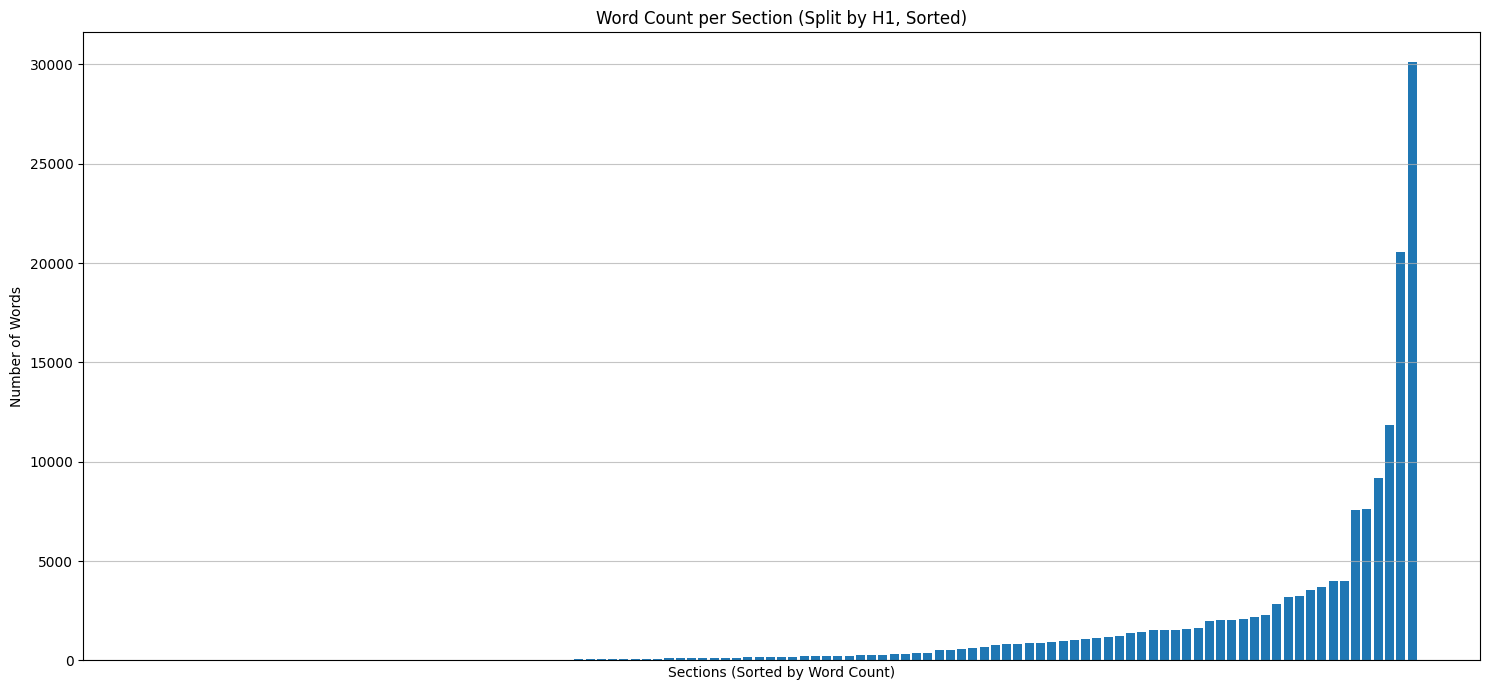


Analyzed 113 sections.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming all_sections_data is available from the previous cell (rkS3olTxEEvC)

# Check if all_sections_data is defined
if 'all_sections_data' not in globals():
    print("Variable 'all_sections_data' not found. Please run the previous cell (rkS3olTxEEvC) first.")
else:
    sections = [sec for sec in all_sections_data]

    # Calculate word count for each section's content
    section_word_counts = [(sec['h1'], len(sec["content"].split())) for sec in sections]

    # Sort sections by word count
    sorted_sections_by_word_count = sorted(section_word_counts, key=lambda item: item[1])

    # Prepare data for plotting
    word_counts = [item[1] for item in sorted_sections_by_word_count]

    # Create the bar plot
    plt.figure(figsize=(15, 7)) # Increased figure size for better readability
    plt.bar(range(len(word_counts)), word_counts)
    plt.xlabel("Sections (Sorted by Word Count)")
    plt.ylabel("Number of Words")
    plt.title("Word Count per Section (Split by H1, Sorted)")
    plt.xticks([]) # Remove x-axis ticks and labels
    plt.tight_layout() # Adjust layout
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    print(f"\nAnalyzed {len(sections)} sections.")

In [ ]:
# Filter sections where the 'h1' does not start with "Beginning of"
filtered_sections = [
    section for section in all_sections_data if not section['h1'].startswith("Beginning of")
]

print(f"\nFound {len(filtered_sections)} sections not starting with 'Beginning of':")

# You can display or further process the filtered_sections here
# For example, printing the h1 of each filtered section:
print("\nH1 headings of filtered sections:")
print("=" * 40)
for section in filtered_sections:
    print(section['h1'])


Found 84 sections not starting with 'Beginning of':

H1 headings of filtered sections:
Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta	4
Flux operational Inrolare si deschidere cont persoana juridica prin corespondenta
I.	PREAMBUL
II. DEFINITII
III. PREVEDERI GENERALE APLICABILE DESCHIDERII CONTURILOR, OPERAREA PE CONTURI ŞI ÎNCHIDEREA RELAŢIEI DE AFACERI
IV.	OPERAȚIUNI CU INSTRUMENTE DE PLATĂ și GARANȚII BANCARE
V.	OPERAȚIUNI CU INSTRUMENTE MONETARE NEGOCIABILE
VI.	GARANȚII ASIGURATORII
VII.	DOBÂNZI / COMISIOANE / SPEZE / COSTURI
VIII. PRODUSE ȘI SERVICII BANCARE
IX. ALTE CLAUZE
Anexa Documente utilizate in proces
Flux operational Autorizare date identificare PJ
II. EMITEREA CERTIFICATULUI CONSTATATOR
IV. Contabilitate – Alimentarea userilor
CAPITOLUL 1. PREVEDERI GENERALE	4
CAPITOLUL 2. INROLAREA SI ACTUALIZAREA DATELOR	9
CAPITOLUL 3. ACTIVAREA/MODIFICAREA/REZILIEREA PRODUSELOR SI SERVICIILOR BANCARE	17
CAPITOLUL 4. EFECTUAREA UNOR OPERATIUNI BANCAR

### Search for h1s not chunked

In [ ]:
# Assuming all_sections_data is available from a previous cell (e.g., rkS3olTxEEvC)

# Check if all_sections_data is defined
if 'all_sections_data' not in globals():
    print("Variable 'all_sections_data' not found. Please run the section splitting cell first.")
else:
    print("Sections in all_sections_data that start with 'Beginning of':")
    print("=" * 60)

    found_sections = []

    # Iterate through each section in all_sections_data
    for section in all_sections_data:
        # Skip sections that start with "Beginning of"
        if section['h1'].startswith("Beginning of"):
            continue

        # Check if the H1 heading of the current section exists as text in any paragraph
        h1_text = section['h1'].strip()
        found_in_paragraph = False
        for paragraph in paragraph_data:
            if paragraph["text"].strip() == h1_text:
                found_in_paragraph = True
                break

        if not found_in_paragraph:
            found_sections.append(section)

    if found_sections:
        print(f"Found {len(found_sections)} sections whose H1 heading also appears as a paragraph:")
        for section in found_sections:
            print(f"Document: {section['docx_name']}")
            print(f"H1 Heading: {section['h1']}")
            print("\n") # Separator for readability
    else:
        print("No sections found whose H1 heading also appears as a paragraph.")

Sections in all_sections_data that start with 'Beginning of':
Found 2 sections whose H1 heading also appears as a paragraph:
Document: Instructiune privind identificarea beneficiarului real in cazul clientilor persoane juridice.docx
H1 Heading: Unnamed H1 (Heading 1)


Document: Flux alternativ actualizare clienti LargeCo.docx
H1 Heading: Unnamed H1 (Heading 1)




In [ ]:
# Assuming paragraph_data is available from a previous cell (e.g., htL9bIx6-sJ7)

# Check if paragraph_data is defined
if 'paragraph_data' not in globals():
    print("Variable 'paragraph_data' not found. Please run the paragraph analysis cell first.")
else:
    search_snippets = [
        "I. PREAMBUL",
        "II. DEFINITII",
        "III. PREVEDERI GENERALE APLICABILE DESCHIDERII CONTURILOR, OPERAREA PE CONTURI ŞI ÎNCHIDEREA RELAŢIEI DE AFACERI",
        "IV. OPERAȚIUNI CU INSTRUMENTE DE PLATĂ și GARANȚII BANCARE",
        "V. OPERAȚIUNI CU INSTRUMENTE MONETARE NEGOCIABILE",
        "VI. GARANȚII ASIGURATORII",
        "VII. DOBÂNZI / COMISIOANE / SPEZE / COSTURI",
        "VIII. PRODUSE ȘI SERVICII BANCARE",
        "IX. ALTE CLAUZE",
        "Anexa Documente utilizate in proces",
        "Flux operational Autorizare date identificare PJ",
        "II. EMITEREA CERTIFICATULUI CONSTATATOR",
        "IV. Contabilitate – Alimentarea userilor",
        "PREZENTARE GENERALA",
        "ABREVIERI",
        "ROLURI IMPLICATE IN PROCES",
        "MOD DE LUCRU",
        "Cap. I. Scopul elaborarii politicii",
        "Cap. II. Cadrul General. Obiective",
        "Cap. III. Cadrul legislativ",
        "Cap. IV. Cadrul de organizare",
        "Cap. V. Modul de abordare a cerintelor legislative",
        "Cap.VI. Politica BT privind aplicarea standardelor",
        "Cap. VII. Politica BT privind aplicarea standardelor",
        "Cap. VIII. Dispozitii generale",
        "MOD DE LUCRU INROLARE IN UNITATE",
        "MOD DE LUCRU ÎNROLARE ASISTATĂ",
        "SUPERVIZAREA",
        "Flux operational – Autorizare date cont/drepturi de operare",
        "Flux actualizare a datelor in Front Office (la ghiseu)",
        "Flux alternativ de actualizare date in backoffice",
        "Unnamed H1 (Heading 1)",
        "1. Scopul instructiunii", # Start of the numbered list
        "2. Notiunea de beneficiar real",
        "3. Identificarea beneficiarului real in functie de tipul persoanei juridice",
        "4. Aspecte legislative",
        "5. Verificarea identității beneficiarului real si completarea informatiilor in aplicatia de inrolare",
        "6. Tipul documentelor acceptate/ colectarea informatiilor in procesul de identificare a beneficiarului real /declaratia de beneficiar real",
        "7. Situatii particulare de analiza", # End of the numbered list
        "4. Flux operational privind executarea operatiunilor ordonate prin intermediul contului de consemnare",
        "Deschiderea relatiei de afaceri/inrolare - Persoana Fizica",
        "Deschiderea relatiei de afaceri/Inrolare Persoana Juridica",
        "III. Gestionarea dosarului electronic al clientului persoana fizica sau juridica",
        "IV. Incetarea relatiei de afaceri cu banca",
        "Anexa 1 Precizari privind documentele de identitate",
        "I. Scopul si domeniul de aplicare",
        "III. Descrierea etapelor si responsabilitatile rolurilor implicate",
        "BISERICA ORTODOXĂ ROMÂNĂ (PAROHIA)"
    ]

    print("Searching for specified text snippets and their styles:")
    print("=" * 60)

    found_matches = []

    for snippet in search_snippets:
        for paragraph in paragraph_data:
            paragraph_text = paragraph["text"].strip()
            style_name = paragraph["style_name"]
            doc_name = paragraph["document_name"]

            # Check if the paragraph text exactly matches the snippet (case-insensitive and ignoring leading/trailing whitespace)
            if paragraph_text.lower() == snippet.lower():
                found_matches.append({
                    "snippet": snippet,
                    "document_name": doc_name,
                    "style_name": style_name
                })

    # Print the details of the found matches
    if found_matches:
        print(f"Found {len(found_matches)} matches for the specified snippets.")
        for match in found_matches:
            print(f"Snippet: {match['snippet']}")
            print(f"Document: {match['document_name']}")
            print(f"Style: {match['style_name']}")
            print("-" * 20) # Separator for readability
    else:
        print("No exact matches found for the specified text snippets.")

Searching for specified text snippets and their styles:
Found 47 matches for the specified snippets.
Snippet: II. DEFINITII
Document: Conditiile generale de afaceri PJ.docx
Style: Heading 1
--------------------
Snippet: III. PREVEDERI GENERALE APLICABILE DESCHIDERII CONTURILOR, OPERAREA PE CONTURI ŞI ÎNCHIDEREA RELAŢIEI DE AFACERI
Document: Conditiile generale de afaceri PJ.docx
Style: Heading 1
--------------------
Snippet: VIII. PRODUSE ȘI SERVICII BANCARE
Document: Conditiile generale de afaceri PJ.docx
Style: Heading 1
--------------------
Snippet: IX. ALTE CLAUZE
Document: Conditiile generale de afaceri PJ.docx
Style: Heading 1
--------------------
Snippet: Anexa Documente utilizate in proces
Document: Flux operational Modificare drepturi de operare imputernicit-delegat.docx
Style: Heading 1
--------------------
Snippet: Anexa Documente utilizate in proces
Document: Flux operational Autorizare date cont drepturi de operare PJ.docx
Style: Heading 1
--------------------
Snippet: Ane

Now that we have split the documents by H1 headings, we can proceed to split them further by H2 and H3 headings to create more granular chunks for better retrieval.

## cache all_sections_data and paragraph_data

In [ ]:
import pickle
import os

# Define the directory for caching
cache_dir = "/content/cache_data"
os.makedirs(cache_dir, exist_ok=True)

# Define the file paths for caching
all_sections_data_cache_path = os.path.join(cache_dir, "all_sections_data.pkl")
paragraph_data_cache_path = os.path.join(cache_dir, "paragraph_data.pkl")

# Check if the variables exist and save them
if 'all_sections_data' in globals():
    with open(all_sections_data_cache_path, 'wb') as f:
        pickle.dump(all_sections_data, f)
    print(f"✅ Variabila 'all_sections_data' a fost salvată în '{all_sections_data_cache_path}'")
else:
    print("❌ Variabila 'all_sections_data' nu este definită. Nu s-a putut salva.")

if 'paragraph_data' in globals():
    with open(paragraph_data_cache_path, 'wb') as f:
        pickle.dump(paragraph_data, f)
    print(f"✅ Variabila 'paragraph_data' a fost salvată în '{paragraph_data_cache_path}'")
else:
    print("❌ Variabila 'paragraph_data' nu este definită. Nu s-a putut salva.")

✅ Variabila 'all_sections_data' a fost salvată în '/content/cache_data/all_sections_data.pkl'
✅ Variabila 'paragraph_data' a fost salvată în '/content/cache_data/paragraph_data.pkl'


In [ ]:
import zipfile
import os
from google.colab import files

# Define the directory to zip
cache_dir = "/content/cache_data"
zip_filename = "cache_data.zip"

# Create the zip file
if os.path.exists(cache_dir):
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, _, files_in_dir in os.walk(cache_dir):
            for file in files_in_dir:
                file_path = os.path.join(root, file)
                zipf.write(file_path, os.path.relpath(file_path, cache_dir))
    print(f"✅ Folderul '{cache_dir}' a fost arhivat în '{zip_filename}'")

    # Offer the file for download
    files.download(zip_filename)
    print(f"✅ Fișierul '{zip_filename}' este gata pentru descărcare.")
else:
    print(f"❌ Directorul '{cache_dir}' nu a fost găsit.")

✅ Folderul '/content/cache_data' a fost arhivat în 'cache_data.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Fișierul 'cache_data.zip' este gata pentru descărcare.


In [ ]:
from google.colab import files
import zipfile
import os

# Upload the zip file
uploaded = files.upload()

# Assuming the uploaded file is 'cache_data.zip'
zip_name = "cache_data.zip"
extract_dir = "/content/cache_data"

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
if os.path.exists(zip_name):
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"✅ Fișierul '{zip_name}' a fost dezarhivat în '{extract_dir}'")
else:
    print(f"❌ Fișierul '{zip_name}' nu a fost găsit.")

Saving cache_data.zip to cache_data.zip
✅ Fișierul 'cache_data.zip' a fost dezarhivat în '/content/cache_data'


In [ ]:
import pickle
import os

# Define the directory for caching
cache_dir = "/content/cache_data"
all_sections_data_cache_path = os.path.join(cache_dir, "all_sections_data.pkl")
paragraph_data_cache_path = os.path.join(cache_dir, "paragraph_data.pkl")

# Load cached data if available
all_sections_data = None
paragraph_data = None

if os.path.exists(all_sections_data_cache_path):
    with open(all_sections_data_cache_path, 'rb') as f:
        all_sections_data = pickle.load(f)
    print(f"✅ Variabila 'all_sections_data' a fost încărcată din '{all_sections_data_cache_path}'")
else:
    print("❌ Variabila 'all_sections_data' nu a fost găsită în cache. Rulați celula de salvare.")

if os.path.exists(paragraph_data_cache_path):
    with open(paragraph_data_cache_path, 'rb') as f:
        paragraph_data = pickle.load(f)
    print(f"✅ Variabila 'paragraph_data' a fost încărcată din '{paragraph_data_cache_path}'")
else:
    print("❌ Variabila 'paragraph_data' nu a fost găsită în cache. Rulați celula de salvare.")

✅ Variabila 'all_sections_data' a fost încărcată din '/content/cache_data/all_sections_data.pkl'
✅ Variabila 'paragraph_data' a fost încărcată din '/content/cache_data/paragraph_data.pkl'


## Load

In [ ]:
from docx import Document as DocxDocument
from langchain.docstore.document import Document
import pandas as pd
import os

def docx_to_documents(docx_path):
    """
    Extracts text and tables from a .docx file, returning LangChain Documents.
    Text and each table are stored as separate Documents, with tables as pandas DataFrames in metadata.
    Args:
        docx_path (str): Path to the .docx file.
    Returns:
        List[Document]: List of LangChain Documents (text and tables).
    """
    doc = DocxDocument(docx_path)
    documents = []
    text_content = []
    table_count = 0

    for element in doc.element.body:
        if element.tag.endswith('p'):
            paragraph = docx.text.paragraph.Paragraph(element, doc)
            if paragraph.text.strip():  # Skip empty paragraphs
                text_content.append(paragraph.text)
        elif element.tag.endswith('tbl'):
            table = docx.table.Table(element, doc)
            # Convert table to pandas DataFrame
            table_data = [[cell.text.strip() for cell in row.cells] for row in table.rows]
            if table_data and any(cell for row in table_data for cell in row):  # Skip empty tables
                df = pd.DataFrame(table_data[1:], columns=table_data[0] if table_data else None)
                # Create a Document for the table
                table_description = f"Table {table_count} from {os.path.basename(docx_path)}"
                documents.append(Document(
                    page_content=table_description,  # Embeddable description
                    metadata={
                        "source": docx_path,
                        "type": "table",
                        "table_index": table_count,
                        "table_df": df  # Store DataFrame in metadata
                    }
                ))
                table_count += 1

    # Create a Document for text content
    if text_content:  # Only if there's non-empty text
        documents.append(Document(
            page_content="\n".join(text_content),
            metadata={"source": docx_path, "type": "text"}
        ))

    return documents

# Load all documents
all_documents = []
docx_folder = extract_dir + "/Norme_BT"
for filename in os.listdir(docx_folder):
    if filename.endswith(".docx"):
        file_path = os.path.join(docx_folder, filename)
        all_documents.extend(docx_to_documents(file_path))

print(f"Loaded {len(all_documents)} documents (text and tables).")

Loaded 164 documents (text and tables).


In [ ]:
import docx
import os

# Assuming extract_dir is defined and contains the extracted docx files
extract_dir = "/content/docx_folder"
docx_folder = os.path.join(extract_dir, "Norme_BT")

# Find the first docx file in the directory
first_docx_file = None
if os.path.exists(docx_folder):
    for filename in os.listdir(docx_folder):
        if filename.endswith(".docx"):
            first_docx_file = os.path.join(docx_folder, filename)
            break

if first_docx_file:
    print(f"Analyzing first DOCX file for headings: {os.path.basename(first_docx_file)}")
    doc = docx.Document(first_docx_file)

    first_h1 = None
    first_h2 = None
    first_h3 = None
    first_p = None

    # Iterate through paragraphs to find headings
    for paragraph in doc.paragraphs:
        style_name = paragraph.style.name
        text = paragraph.text.strip()

        if not first_p:
            first_p = text
            print(f"First p: {first_p}")
            print(style_name)

        if style_name == 'Title' and not first_h1:
            first_h1 = text
            print(f"First Title: {first_h1}")
        elif style_name == 'Heading2' and not first_h2:
            first_h2 = text
            print(f"First H2 Heading: {first_h2}")
        elif style_name == 'Heading3' and not first_h3:
            first_h3 = text
            print(f"First H3 Heading: {first_h3}")

        # Stop if all desired headings are found
        if first_h1 and first_h2 and first_h3:
            break

    if not first_h1:
        print("First H1 Heading: No H1 heading found")
    if not first_h2:
        print("First H2 Heading: No H2 heading found")
    if not first_h3:
        print("First H3 Heading: No H3 heading found")

else:
    print(f"No .docx files found in {docx_folder}. Please ensure the zip file was uploaded and extracted correctly.")

Analyzing first DOCX file for headings: Instructiune privind identificarea beneficiarului real in cazul clientilor persoane juridice.docx
First p: 
Normal
First p: 
Texte
First p: Lista de distributie interna :
Title
First H1 Heading: No H1 heading found
First H2 Heading: No H2 heading found
First H3 Heading: No H3 heading found


## Split

In [ ]:
from transformers import AutoTokenizer

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("intfloat/multilingual-e5-small")

# Initialize text splitter for text documents
text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
    tokenizer,
    chunk_size=200,  # Increased for better context
    chunk_overlap=20,  # 10% overlap
    strip_whitespace=True,
    separators=["\n\n", "\n", ".", "!", "?", " ", ""],  # Added ! and ? for technical docs
)

# Split documents, keeping tables intact
docs = []
for doc in all_documents:
    if doc.metadata["type"] == "text":
        # Split text documents
        split_docs = text_splitter.split_documents([doc])
        docs.extend(split_docs) # extend makes an append for each element of the split_docs (for each chunk)
    else:
        # Keep table documents intact
        docs.append(doc)

print(f"Split into {len(docs)} chunks (text chunks and full tables).")

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (6587 > 512). Running this sequence through the model will result in indexing errors


Split into 1798 chunks (text chunks and full tables).


## Embed

In [ ]:
# Initialize embeddings
embeddings = HuggingFaceEmbeddings(model_name="intfloat/multilingual-e5-small")

# Batch embedding
def batch_embed_documents(docs, batch_size=32):
    texts = [doc.page_content for doc in docs]
    batches = [texts[i:i + batch_size] for i in range(0, len(texts), batch_size)]
    embedded_docs = []

    for batch in tqdm(batches, desc="Embedding documents"):
        batch_embeddings = embeddings.embed_documents(batch)
        embedded_docs.extend(batch_embeddings)

    return list(zip(texts, embedded_docs))

# Embed documents
text_embeddings = batch_embed_documents(docs)

# Create FAISS vector store with metadata
vectorstore = FAISS.from_embeddings(
    text_embeddings=text_embeddings,
    embedding=embeddings,
    metadatas=[doc.metadata for doc in docs]
)

print("Created FAISS vector store.")

/tmp/ipython-input-3850737679.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="intfloat/multilingual-e5-small")


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Embedding documents:   0%|          | 0/57 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Created FAISS vector store.


In [ ]:
vectorstore.save_local("faiss_index")

# RAG

## Upload index

In [ ]:
from google.colab import files

uploaded = files.upload()  # selectezi faiss_index.zip


Saving faiss-p-tbl.zip to faiss-p-tbl.zip


## vectorstore

In [ ]:
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import FAISS

import zipfile
with zipfile.ZipFile("faiss-p-tbl.zip", 'r') as zip_ref:
    zip_ref.extractall("faiss_index")

# Folosim același model de embedding multilingual
embeddings = HuggingFaceEmbeddings(model_name="intfloat/multilingual-e5-small")
vectorstore = FAISS.load_local("faiss_index/faiss-p-tbl", embeddings, allow_dangerous_deserialization=True)

/tmp/ipython-input-2138703568.py:9: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="intfloat/multilingual-e5-small")


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

## Create Reranker

Reranker-ul îmbunătățește ordinea documentelor returnate de retriever, oferind rezultate mai precise pentru query-ul utilizatorului.

In [ ]:
from sentence_transformers import CrossEncoder
import numpy as np
from typing import List, Tuple

class CustomReranker:
    def __init__(self, model_name: str = "corrius/cross-encoder-mmarco-mMiniLMv2-L12-H384-v1"):
        """
        Inițializează reranker-ul cu un model cross-encoder multilingual.
        Acest model este optimizat pentru limba română și alte limbi.
        """
        print(f"Încarcă reranker-ul: {model_name}")
        self.model = CrossEncoder(model_name)

    def rerank(self, query: str, documents: List[str], top_k: int = 3) -> List[Tuple[str, float]]:
        """
        Reordonează documentele pe baza relevanței față de query.

        Args:
            query: Query-ul utilizatorului
            documents: Lista de documente
            top_k: Numărul de documente top să returneze

        Returns:
            Lista de tuple (document, score) ordonate descrescător
        """
        if not documents:
            return []

        # Creează perechile query-document pentru cross-encoder
        query_doc_pairs = [(query, doc) for doc in documents]

        # Calculează scorurile de relevență
        scores = self.model.predict(query_doc_pairs)

        # Combină documentele cu scorurile lor
        doc_scores = list(zip(documents, scores))

        # Sortează descrescător după scor și returnează top_k
        doc_scores.sort(key=lambda x: x[1], reverse=True)

        return doc_scores[:top_k]

# Inițializează reranker-ul
reranker = CustomReranker()
print("✅ Reranker multilingual încărcat cu succes!")

Încarcă reranker-ul: corrius/cross-encoder-mmarco-mMiniLMv2-L12-H384-v1


config.json:   0%|          | 0.00/891 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/471M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

✅ Reranker multilingual încărcat cu succes!


## RerankingRetriever

In [ ]:
from langchain.schema import BaseRetriever, Document
from typing import List, Any

class RerankingRetriever(BaseRetriever):
    """
    Retriever custom care combină FAISS cu reranking pentru rezultate îmbunătățite.
    """

    def __init__(self, vectorstore, reranker, k: int = 8, rerank_k: int = 1):
        super().__init__()
        self._vectorstore = vectorstore
        self._reranker = reranker
        self._k = k
        self._rerank_k = rerank_k

    def _get_relevant_documents(self, query: str) -> List[Document]:
        """
        Obține documentele relevante prin combinația FAISS + reranking.
        """
        # Pas 1: Obține documentele candidate cu FAISS
        initial_docs = self._vectorstore.similarity_search(query, k=self._k)

        if not initial_docs:
            return []

        # Pas 2: Extrage conținutul documentelor
        doc_contents = [doc.page_content for doc in initial_docs]

        # Pas 3: Aplică reranking-ul
        reranked_results = self._reranker.rerank(query, doc_contents, top_k=self._rerank_k)

        # Pas 4: Creează obiectele Document pentru rezultatele reranked
        reranked_docs = []
        for content, score in reranked_results:
            # Găsește documentul original pentru a păstra metadata
            original_doc = next(doc for doc in initial_docs if doc.page_content == content)
            # Adaugă scorul de reranking în metadata
            original_doc.metadata['rerank_score'] = float(score)
            reranked_docs.append(original_doc)

        return reranked_docs

    async def _aget_relevant_documents(self, query: str) -> List[Document]:
        """Versiunea async a funcției _get_relevant_documents."""
        return self._get_relevant_documents(query)

# Creează retriever-ul cu reranking
enhanced_retriever = RerankingRetriever(
    vectorstore=vectorstore,
    reranker=reranker,
    k=8,  # Ia 8 documente din FAISS
    rerank_k=3  # Returnează top 3 după reranking
)

print("✅ Retriever cu reranking creat cu succes!")

✅ Retriever cu reranking creat cu succes!


## Test enhanced_retriever

In [ ]:
# Metodă publică pentru testare directă a retriever-ului
def get_relevant_documents(retriever, query: str):
    """
    Wrapper public pentru testarea retriever-ului.
    """
    return retriever._get_relevant_documents(query)

# Test rapid al retriever-ului
print("🧪 Testez retriever-ul cu reranking...")
test_query = "procedura deschidere cont"
test_docs = get_relevant_documents(enhanced_retriever, test_query)
print(f"✅ Retriever funcționează! Găsite {len(test_docs)} documente pentru: '{test_query}'")

🧪 Testez retriever-ul cu reranking...
✅ Retriever funcționează! Găsite 3 documente pentru: 'procedura deschidere cont'


## Prompt

In [ ]:
from langchain.prompts import PromptTemplate

# banking_prompt = PromptTemplate(
#     input_variables=["context", "question"],
#     template="""
#     Ești un asistent bancar util și politicos. Scopul tău este să oferi răspunsuri clare, concise și umane în limba română, bazate pe contextul oferit.

#     Instrucțiuni:
#     - Nu copia contextul. Folosește-l pentru a răspunde cât mai natural.
#     - De exemplu, dacă întrebarea este despre "câți pași", numără pașii și oferă răspunsul într-o propoziție clară (ex: "Sunt 5 pași în total.").
#     - DACA se cere o procedură, oferă pașii numerotați.
#     - Păstrează un ton prietenos și profesional.
#     - Răspunde complet și nu te opri brusc.

#     Întrebare: {question}

#     Context: {context}

#     Răspuns:
#     """
# )

# banking_prompt = PromptTemplate(
#     input_variables=["context", "question"],
#     template="""Ești un asistent bancar. Răspunde în română, clar si complet, pe baza contextului.

# Întrebare: {question}

# Context: {context}

# Răspuns:"""
# )

banking_prompt = PromptTemplate(
    input_variables=["context", "question"],
    template="""Ești un asistent util de suport bancar. Folosește informațiile extrase din baza de cunoștințe pentru a răspunde în limba română cu exactitate la întrebarea clientului. Asigură-te că răspunsul este concis, politicos și formulat într-un limbaj simplu. Dacă răspunsul nu este disponibil, informează politicos clientul.

Întrebare: {question}

Context: {context}

Răspuns:"""
)

## LLM/Tokenizer

In [ ]:
from langchain.llms import HuggingFacePipeline
from langchain.chains import RetrievalQA
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch
from google.colab import userdata
from huggingface_hub import login

# Model optimizat pentru română și banking - Mistral este excelent pentru română
model_name = "mistralai/Mistral-7B-Instruct-v0.2"  # Versiunea mai nouă

print(f"Încarcă modelul {model_name}...")

# Log in to Hugging Face using the token stored in Colab secrets
try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    print("✅ Authenticated with Hugging Face successfully!")
except Exception as e:
    print(f"❌ Failed to authenticate with Hugging Face: {e}")
    print("Please make sure you have added your HF_TOKEN to Colab secrets and accepted the model's terms on Hugging Face.")

# Configurare pentru a folosi mai puțină memorie în Colab
# bnb_config = BitsAndBytesConfig(
#     load_in_8bit=True,
#     bnb_8bit_quant_type="nf8",
#     bnb_8bit_compute_dtype=torch.float16,
#     bnb_8bit_use_double_quant=True,
# )

tokenizer = AutoTokenizer.from_pretrained(model_name)
# print(torch.cuda.is_available())
# model = AutoModelForCausalLM.from_pretrained(
#     model_name,
#     quantization_config=bnb_config,
#     torch_dtype=torch.float16,
#     device_map="cuda",
#     trust_remote_code=True
# )

# Asigură-te că tokenizer-ul are pad_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

hf_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=350,
    temperature=0.3,
    num_beams=3,
    do_sample=True,
    # top_p=0.9,
    # top_k=40, # it controls how many tokens the model considers at each decoding step
    repetition_penalty=1.2,
    eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.eos_token_id,
    return_full_text=False
)

llm = HuggingFacePipeline(pipeline=hf_pipeline)

# Creează chain-ul pentru QA cu retriever îmbunătățit
# qa_chain = RetrievalQA.from_chain_type(
#     llm=llm,
#     chain_type="stuff",
#     retriever=enhanced_retriever,  # Folosește retriever-ul cu reranking
#     return_source_documents=True,  # Returnează și documentele sursă
#     verbose=True,  # Pentru debugging
#     chain_type_kwargs={"prompt": banking_prompt}
# )

Încarcă modelul mistralai/Mistral-7B-Instruct-v0.2...
✅ Authenticated with Hugging Face successfully!


tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Device set to use cuda:0
/tmp/ipython-input-1690227096.py:60: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=hf_pipeline)


## Save the Model

You don’t need to reload the model every time just to test different temperature, top_p, or max_new_tokens. You can recreate the pipeline with different parameters without rebuilding the model:

In [ ]:
model.save_pretrained("/content/drive/mistral_model/")
tokenizer.save_pretrained("/content/drive/mistral_tokenizer/")


('/content/drive/MyDrive/mistral_tokenizer/tokenizer_config.json',
 '/content/drive/MyDrive/mistral_tokenizer/special_tokens_map.json',
 '/content/drive/MyDrive/mistral_tokenizer/chat_template.jinja',
 '/content/drive/MyDrive/mistral_tokenizer/tokenizer.model',
 '/content/drive/MyDrive/mistral_tokenizer/added_tokens.json',
 '/content/drive/MyDrive/mistral_tokenizer/tokenizer.json')

## Reload Mistral local

In [ ]:
from google.colab import files
uploaded = files.upload()
!unzip -q mistral_model.zip -d /
model_path = "/mistral_model"
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch
bnb_config = BitsAndBytesConfig(load_in_8bit=True, bnb_8bit_quant_type="nf8",
                                bnb_8bit_compute_dtype=torch.float16, bnb_8bit_use_double_quant=True)
# tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

KeyboardInterrupt: 

## Reload mistral from huggingface

In [ ]:
from huggingface_hub import snapshot_download
model_path = snapshot_download("stefansandru/plant-care-mistral")


## Reload mistral drive

In [ ]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
import torch
from google.colab import drive
import os

# Mount Google Drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the path to the saved model on Google Drive
model_path = "/content/drive/MyDrive/mistral_model/"

# Configure BitsAndBytesConfig for 8-bit quantization (matching the previous successful load attempt)
# Adjust this config as needed based on how the model was saved
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_quant_type="nf8",
    bnb_8bit_compute_dtype=torch.float16,
    bnb_8bit_use_double_quant=True,
    llm_int8_enable_fp32_cpu_offload=True, # If this was used during saving
)

model = None

try:
    # Load model
    if os.path.exists(model_path):
        print(f"Attempting to load model from local path: {model_path}")
        model = AutoModelForCausalLM.from_pretrained(
            model_path,
            quantization_config=bnb_config,
            torch_dtype=torch.float16, # Use the same dtype as during saving
            device_map="auto", # Automatically set device
            trust_remote_code=True
        )
        print("✅ Mistral model loaded from Drive.")
    else:
        print(f"❌ Model path {model_path} does not exist.")
        print("Trying to load Mistral base model from Hugging Face...")
        base_model_name = "mistralai/Mistral-7B-Instruct-v0.2"
        model = AutoModelForCausalLM.from_pretrained(
             base_model_name,
             quantization_config=bnb_config,
             torch_dtype=torch.float16,
             device_map="auto",
             trust_remote_code=True
        )
        print("✅ Mistral base model loaded from Hugging Face.")


except Exception as e:
    print(f"❌ An unexpected error occurred during loading: {e}")
    model = None # Set model to None if loading fails


if model:
    print(f"✅ Model loaded successfully.")
else:
    print(f"❌ Failed to load model.")

Mounted at /content/drive
Attempting to load model from local path: /content/drive/MyDrive/mistral_model/


`torch_dtype` is deprecated! Use `dtype` instead!
/usr/local/lib/python3.12/dist-packages/transformers/quantizers/auto.py:239: UserWarning: You passed `quantization_config` or equivalent parameters to `from_pretrained` but the model you're loading already has a `quantization_config` attribute. The `quantization_config` from the model will be used.
  warnings.warn(warning_msg)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Mistral model loaded from Drive.
✅ Model loaded successfully.


## Reload Tapas

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

tapas_model_path = "/content/drive/MyDrive/tapas_model/"
tapas_tokenizer_path = "/content/drive/MyDrive/tapas_tokenizer/"

tapas_tokenizer = TapasTokenizer.from_pretrained(tapas_model_path)
tapas_model = TapasForQuestionAnswering.from_pretrained(tapas_tokenizer_path)



## Tapas



In [ ]:
# from langchain.schema import BaseRetriever, Document
# from langchain.chains import RetrievalQA
from transformers import TapasTokenizer, TapasForQuestionAnswering
import pandas as pd

# Initialize TAPAS
tapas_model_name = "google/tapas-base-finetuned-wtq"
tapas_tokenizer = TapasTokenizer.from_pretrained(tapas_model_name)
tapas_model = TapasForQuestionAnswering.from_pretrained(tapas_model_name)

# # Save Tapas
# tapas_model.save_pretrained("/content/drive/MyDrive/tapas_model/")
# tapas_tokenizer.save_pretrained("/content/drive/MyDrive/tapas_tokenizer/")


## TableTextQAChain

In [ ]:
from langchain.schema import BaseRetriever, Document
from langchain.chains import RetrievalQA
from transformers import TapasTokenizer, TapasForQuestionAnswering
import pandas as pd
from typing import List, Dict, Any
import time

# Assume tapas_tokenizer and tapas_model are initialized elsewhere
# Assume is_table_query function is defined elsewhere

class TableTextQAChain:
    def __init__(self, retriever: BaseRetriever, llm: Any, prompt: PromptTemplate):
        self.retriever = retriever
        self.llm = llm
        self.prompt = prompt

    def invoke(self, inputs: Dict[str, str]) -> Dict[str, Any]:
        query = inputs["query"]

        # Retrieve documents
        start_retrieval = time.time()
        docs = self.retriever.invoke(query)
        end_retrieval = time.time()
        retrieval_time = end_retrieval - start_retrieval

        # Separate text and table documents
        text_docs = [doc for doc in docs if doc.metadata["type"] == "text"]
        table_docs = [doc for doc in docs if doc.metadata["type"] == "table"]

        context = []

        # Process table documents with TAPAS
        if is_table_query(query) and table_docs:
            for table_doc in table_docs:
                table = table_doc.metadata.get("table_df")
                if table is not None and not table.empty:
                    try:
                        inputs = tapas_tokenizer(table=table, queries=query, padding="max_length", return_tensors="pt")
                        outputs = tapas_model(**inputs)
                        coords, agg = tapas_tokenizer.convert_logits_to_predictions(outputs.logits, outputs.logits_aggregation)
                        cells = [table.iloc[row, col] for row, col in coords[0]]
                        if agg == 0:
                            table_answer = ", ".join(str(cell) for cell in cells)
                        else:
                            table_answer = str(eval(f"{tapas_model.config.aggregation_labels[agg].lower()}({[float(c) for c in cells if c]})"))
                        context.append(f"Table answer: {table_answer}")
                    except Exception as e:
                        print(f"Error processing table: {e}")
                        context.append(table_doc.page_content)

        context.extend([doc.page_content for doc in text_docs])
        combined_context = "\n".join(context)

        formatted_prompt = self.prompt.format(context=combined_context, question=query)
        if not formatted_prompt.strip().endswith("Răspuns:"):
            formatted_prompt += "\nRăspuns:"

        # Generate answer with LLM
        start_generation = time.time()
        result = self.llm.invoke(formatted_prompt, stop=["Întrebare:", "Context:", "Instrucțiuni:"])
        end_generation = time.time()
        generation_time = end_generation - start_generation


        return {
            "result": result,
            "source_documents": docs,
            "retrieval_time": retrieval_time,
            "generation_time": generation_time
        }



NameError: name 'enhanced_retriever' is not defined

## QA chain

In [ ]:
qa_chain = TableTextQAChain(
    retriever=enhanced_retriever,
    llm=llm,
    prompt=banking_prompt
)

## Ask

In [ ]:
# Test the pipeline
query = "Da-mi modelul de solicitare  certificat RECOM din Anexa 1 ?"
print("🏦 TESTEAZĂ PIPELINE-UL RAG OPTIMIZAT PENTRU ROMÂNĂ BANKING")
print("=" * 60)
print(f"📋 Query: {query}")
print("\n🔍 Se caută în documentele bancare...")

try:
    result = qa_chain.invoke({"query": query})
    print(f"✅ Găsite {len(result['source_documents'])} documente relevante după reranking")

    # Display reranking scores
    for i, doc in enumerate(result['source_documents']):
        score = doc.metadata.get('rerank_score', 'N/A')
        print(f"   Doc {i+1}: Score reranking = {score}, Type = {doc.metadata.get('type')}")

    print("\n📝 RĂSPUNS FINAL:")
    print("-" * 40)
    print(result['result'])

    print("\n📚 SURSE FOLOSITE:")
    print("-" * 40)
    for i, doc in enumerate(result['source_documents']):
        print(f"Sursa {i+1}: {doc.page_content[:150]}... (Type: {doc.metadata.get('type')})")
except Exception as e:
    print(f"❌ Eroare: {e}")
    print("💡 Încearcă să reduci parametrii modelului sau să folosești un model mai mic")

🏦 TESTEAZĂ PIPELINE-UL RAG OPTIMIZAT PENTRU ROMÂNĂ BANKING
📋 Query: Da-mi modelul de solicitare  certificat RECOM din Anexa 1 ?

🔍 Se caută în documentele bancare...
✅ Găsite 3 documente relevante după reranking
   Doc 1: Score reranking = 9.168487548828125, Type = text
   Doc 2: Score reranking = 8.658249855041504, Type = text
   Doc 3: Score reranking = 0.3590985834598541, Type = text

📝 RĂSPUNS FINAL:
----------------------------------------
 Pentru a solicita un certificat RECOM din Anexa 1, puteți utiliza următorul model de solicitare:

Buna ziua,

Daca certificatul RECOM nu se afla în termenul de valabilitate, se vor aplica pasii descrisi la punctul B 5.4, cu mențiunea că acordul clientului pentru eliberarea extrasului a fost deja preluat prin cadrul Anexei 8.

De la punctul C se respectă pasii cu excepția subpunctului C.4,

De la punctul E se respectă pasii cu excepția subpunctelor E3, E4, E5, E6, E8 și E9.

În cazul în care, în cadrul cererii de actualizare date, nu sunt colect

## Enhance Query Analysis for Table Detection

In [ ]:
def is_table_query(query: str) -> bool:
    table_keywords = ["cât", "suma", "total", "număr", "tabel", "valoare", "preț", "dobândă"]
    return any(keyword in query.lower() for keyword in table_keywords)

# Modify invoke method in TableTextQAChain
def invoke(self, inputs: Dict[str, str]) -> Dict[str, Any]:
    query = inputs["query"]
    docs = self.retriever.invoke(query)

    text_docs = [doc for doc in docs if doc.metadata["type"] == "text"]
    table_docs = [doc for doc in docs if doc.metadata["type"] == "table"]

    context = []

    # Only process tables if query suggests table data
    if is_table_query(query) and table_docs:
        for table_doc in table_docs:
            table = table_doc.metadata.get("table_df")
            if table is not None and not table.empty:
                try:
                    inputs = tapas_tokenizer(table=table, queries=query, padding="max_length", return_tensors="pt")
                    outputs = tapas_model(**inputs)
                    coords, agg = tapas_tokenizer.convert_logits_to_predictions(outputs.logits, outputs.logits_aggregation)
                    cells = [table.iloc[row, col] for row, col in coords[0]]
                    if agg == 0:
                        table_answer = ", ".join(str(cell) for cell in cells)
                    else:
                        table_answer = str(eval(f"{tapas_model.config.aggregation_labels[agg].lower()}({[float(c) for c in cells if c]})"))
                    context.append(f"Table answer: {table_answer}")
                except Exception as e:
                    print(f"Error processing table: {e}")
                    context.append(table_doc.page_content)

    # Always include text documents
    context.extend([doc.page_content for doc in text_docs])

    combined_context = "\n".join(context)
    result = self.llm.invoke(self.prompt.format(context=combined_context, question=query))

    return {
        "result": result,
        "source_documents": docs
    }

## Ask qa_chain

In [ ]:
query = "ce este neobt?"

# query = "Cati pasi sunt pentu Deschide cont colector pentru plata salariilor?"

print(f"Query: {query}")
try:
    # Testează retriever-ul îmbunătățit folosind metoda standard LangChain
    relevant_docs = enhanced_retriever.invoke(query)  # Metodă standard LangChain
    print(f"✅ Găsite {len(relevant_docs)} documente relevante după reranking")

    # Afișează scorurile de reranking
    for i, doc in enumerate(relevant_docs):
        score = doc.metadata.get('rerank_score', 'N/A')
        print(f"   Doc {i+1}: Score reranking = {score}")

    print("\n🤖 Generez răspuns...")

    # Rulează chain-ul QA complet
    result = qa_chain.invoke({"query": query})  # Metodă standard nouă

    print("\n📝 RĂSPUNS FINAL:")
    print("-" * 40)
    print(result['result'])

    print("\n📚 SURSE FOLOSITE:")
    print("-" * 40)
    for i, doc in enumerate(result['source_documents']):
        print(f"Sursa {i+1}: {doc.page_content[:150]}...")

except Exception as e:
    print(f"❌ Eroare: {e}")
    print("💡 Încearcă să reduci parametrii modelului sau să folosești un model mai mic")

Query: ce este neobt?
✅ Găsite 3 documente relevante după reranking
   Doc 1: Score reranking = -0.6107373237609863
   Doc 2: Score reranking = -2.169675827026367
   Doc 3: Score reranking = -2.79162335395813

🤖 Generez răspuns...

📝 RĂSPUNS FINAL:
----------------------------------------
 NeoBT, BT24 sau BT Go sunt aplicații de internet banking care oferă acces la diverse funcționalități bancare. Un token fizic sau electronic este necesar pentru a accesa aceste aplicații și a genera coduri unice de autorizare pentru conexiuni și tranzacții. Această proprietate a băncii poate fi blocată, reactivată sau retrasă oricând. "Imputare NeoBT" nu este o funcționalitate recunoscută a acestor aplicații.

📚 SURSE FOLOSITE:
----------------------------------------
Sursa 1: 3.1. Obiectul prezentului contract constă în accesul la aplicatia de internet banking NeoBT / BT24/BT Go în scopul utilizării tuturor funcționalitățil...
Sursa 2: Token – dispozitiv fizic sau electronic care permite accesul  Neo

## Test Questions

Cate notificari se trimit inainte de scadenta DAU?

care sunt Canale de comunicare

din cate in cate zile se trimit notificari pentur inchiderea contului?

Cati pasi sunt pentu Deschide cont colector pentru plata salariilor?

Cati pasi sunt pentu Deschide cont colector pentru plata salariilor? Vreu sa stiu numarul de pasi?

ce rol are un Ofiter back-office inrolare si mentenanta clienti?

ce este neobt?

Ce functinalitati are **newobt**

**Ce functinalitati are neobt** - nu spuen care sunt

**Cum instalez neobt** - raspunde prea compicat si deloc bine

neobt il pot instala din google sau trbuie sa accesez magazinele online, android sau ios?

**Da-mi modelul de solicitare  certificat RECOM din Anexa 1** ? - nu il da

In [ ]:
# Rulează această celulă după ce ai definit `qa_chain`.
# Printează întrebarea, răspunsul și un newline.

queries = [
    "Cate notificari se trimit inainte de scadenta DAU?",
    "care sunt Canale de comunicare",
    "din cate in cate zile se trimit notificari pentur inchiderea contului?",
    "Cati pasi sunt pentu Deschide cont colector pentru plata salariilor?",
    "Cati pasi sunt pentu Deschide cont colector pentru plata salariilor? Vreu sa stiu numarul de pasi?",
    "ce rol are un Ofiter back-office inrolare si mentenanta clienti?",
    "ce este neobt?",
    "Ce functinalitati are newobt",
    "Ce functinalitati are neobt",
    "Cum instalez neobt",
    "Care este totalul depozit daca am depozitat azi 400 lei, acum o luna 300 lei si acum 3 zile 5 lei?"
]

# if 'qa_chain' not in globals():
#     raise RuntimeError("qa_chain nu este definit. Asigură-te că pipeline-ul RAG (qa_chain) a fost creat.")

def ask(query: str):
    try:
        result = qa_chain.invoke({"query": query})
        answer = result.get("result", "") if isinstance(result, dict) else str(result)
    except Exception as e:
        answer = f"Eroare: {e}"
    print(query)
    print(answer.strip())
    print()  # newline

for q in queries:
    ask(q)

Cate notificari se trimit inainte de scadenta DAU?
În funcție de tipul dvs. contului, dvs. vor primi următoarele notificări înainte de expirarea DAU: 
- Notificarea nr. 2 cu 60 de zile înainte
- Notificarea nr. 3 cu 30 de zile înainte
- Notificarea nr. 4 cu 7 zile înainte
- Notificarea nr. 5 după expirarea DAU
Dacă dvs. nu actualizează datele, conturile dvs. pot fi blocate.

care sunt Canale de comunicare
Canalele de comunicare ale Băncii Transilvania sunt: 1. Formularul de contact de pe site-ul nostru; 2. Mesageria securizată din Internet Banking NeoBT / BT24; 3. Apel – Serviciul Contact Center; 4. Social Media; 5. Personal, la orice sucursală/agenție BT; 6. Componenta de Collaboration; 7. IMM to Go.

din cate in cate zile se trimit notificari pentur inchiderea contului?
În cazul în care ai primit o notificare despre inchiderea contului dvs., conturile subordonate acestuia vor fi, de asemenea, inchise în termenul menționat în notificare. Dacă aveți nevoie de informații suplimentare sa